In [3]:
#自动重载外部文件的更新
%load_ext autoreload
%autoreload 2

# 添加项目路径至path
import os
import sys
currentPath = os.path.join(os.getcwd(),"machinelearningIntro","机器学习实践/回归/多元线性回归")
sys.path.append(currentPath)


In [4]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文乱码问题
plt.rcParams["axes.unicode_minus"] = False  # 使负号正常显示

In [5]:
# 导入数据
datadir = r"D:\PythonEx\machinelearningIntro\data\Penn World Table.xlsx"
df = pd.read_excel(datadir)
df

,countrycode,country,currency_unit,year,rgdpe,pl_c,pl_i,pl_g,pl_x,pl_m,pl_k
0,AGO,Angola,Kwanza,2007,58131.746094,1.253990,0.738191,1.076301,0.650072,0.764166,0.617699
1,AGO,Angola,Kwanza,2008,67472.859375,1.418632,0.938361,1.352946,0.774891,0.937404,0.777646
2,AGO,Angola,Kwanza,2009,59256.636719,1.681747,0.786687,1.105007,0.829843,1.190549,0.657191
3,AGO,Angola,Kwanza,2010,76151.132812,1.195477,0.843884,1.161518,0.920334,0.961341,0.706732
4,AGO,Angola,Kwanza,2011,82680.945312,1.294905,1.048095,1.460608,1.194767,1.239069,0.868282
...,...,...,...,...,...,...,...,...,...,...,...
830,ZWE,Zimbabwe,Zimbabwe Dollar,2007,45666.082031,0.155326,0.096808,0.030871,0.836226,0.704391,1.322423
831,ZWE,Zimbabwe,Zimbabwe Dollar,2008,35789.878906,0.187243,0.075830,0.017838,0.812021,0.899782,0.920607
832,ZWE,Zimbabwe,Zimbabwe Dollar,2009,49294.878906,0.112196,0.211507,0.153393,0.274833,0.375842,3.617210
833,ZWE,Zimbabwe,Zimbabwe Dollar,2010,51259.152344,0.123692,0.237427,0.168766,0.298547,0.407374,4.071371


In [6]:
df.columns

Index(['countrycode', 'country', 'currency_unit', 'year', 'rgdpe', 'pl_c',
       'pl_i', 'pl_g', 'pl_x', 'pl_m', 'pl_k'],
      dtype='object')

In [7]:
df.year.value_counts()

2007    167
2008    167
2009    167
2010    167
2011    167
Name: year, dtype: int64

In [8]:
data = df[['pl_c','pl_i', 'pl_g', 'pl_x', 'pl_m', 'pl_k','rgdpe']]
data = np.log(data)
x_data = df[['pl_c','pl_i', 'pl_g', 'pl_x', 'pl_m', 'pl_k']]
y_data = df[['rgdpe']]

In [9]:
# 探索性分析
data.describe()

,pl_c,pl_i,pl_g,pl_x,pl_m,pl_k,rgdpe
count,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000,835.000000
mean,-0.290392,-0.187144,-0.453663,-0.135787,-0.204165,-0.346885,10.833934
std,0.416546,0.486217,0.716834,0.160531,0.137122,0.580939,2.125492
min,-2.187510,-2.579259,-4.026440,-1.291590,-0.978587,-1.779965,5.487704
25%,-0.545993,-0.475354,-0.900372,-0.207646,-0.290009,-0.732292,9.389024
50%,-0.335342,-0.239924,-0.427703,-0.132980,-0.201642,-0.425493,10.747978
75%,-0.012210,0.066378,0.112809,-0.056968,-0.126762,-0.038758,12.429206
max,1.296542,1.812715,1.002211,0.450231,0.379142,2.227766,16.411739


<AxesSubplot:>

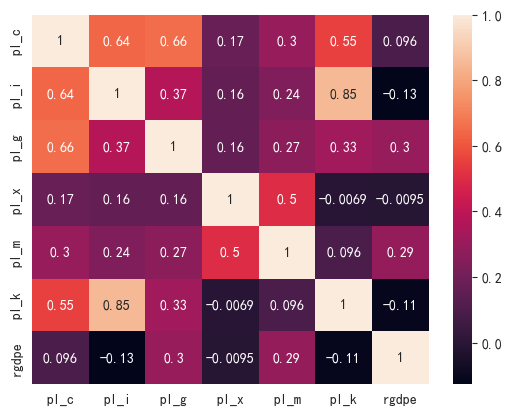

In [10]:
# heatmap看共线性
sns.heatmap(data.corr(),annot=True)

In [11]:
data.corr()

,pl_c,pl_i,pl_g,pl_x,pl_m,pl_k,rgdpe
pl_c,1.000000,0.638262,0.656078,0.174334,0.297147,0.547620,0.095560
pl_i,0.638262,1.000000,0.371734,0.161057,0.238059,0.852176,-0.126312
pl_g,0.656078,0.371734,1.000000,0.160477,0.268314,0.325628,0.296902
pl_x,0.174334,0.161057,0.160477,1.000000,0.501256,-0.006860,-0.009540
pl_m,0.297147,0.238059,0.268314,0.501256,1.000000,0.095693,0.294240
pl_k,0.547620,0.852176,0.325628,-0.006860,0.095693,1.000000,-0.111779
rgdpe,0.095560,-0.126312,0.296902,-0.009540,0.294240,-0.111779,1.000000


In [12]:
data_lg = data[['pl_i', 'pl_g', 'pl_x', 'pl_m', 'rgdpe']]
data_lg.corr()

,pl_i,pl_g,pl_x,pl_m,rgdpe
pl_i,1.000000,0.371734,0.161057,0.238059,-0.126312
pl_g,0.371734,1.000000,0.160477,0.268314,0.296902
pl_x,0.161057,0.160477,1.000000,0.501256,-0.009540
pl_m,0.238059,0.268314,0.501256,1.000000,0.294240
rgdpe,-0.126312,0.296902,-0.009540,0.294240,1.000000


<AxesSubplot:>

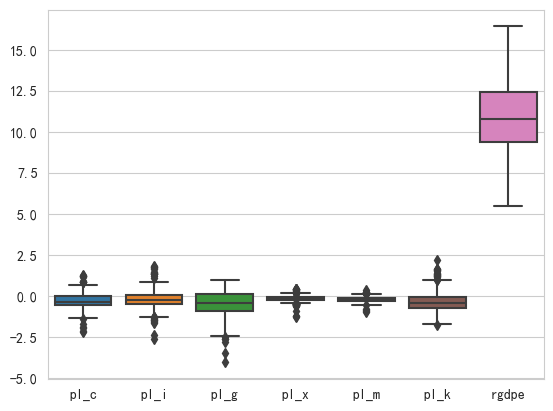

In [13]:
sns.boxplot(data)

In [14]:
#TODO  删去上下四分位之外的极值

In [15]:
from lineartrain_from_老师 import *
import matplotlib.pyplot as plt

In [16]:
#拆分训练集和测试集
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(x_data,y_data,test_size = 0.9,random_state=123456)

In [17]:
loss_his, params, grads = linear_train(X_train,y_train,0.01,1000)
print(params['w'])
print(params['b'])
print(min(loss_his))


[[ 158805.28697196]
 [-128731.2806781 ]
 [ 181636.70651238]
 [  -7916.75456657]
 [  90277.3063448 ]
 [  50112.99703897]]
-8899.913012158784
169131524746.58374


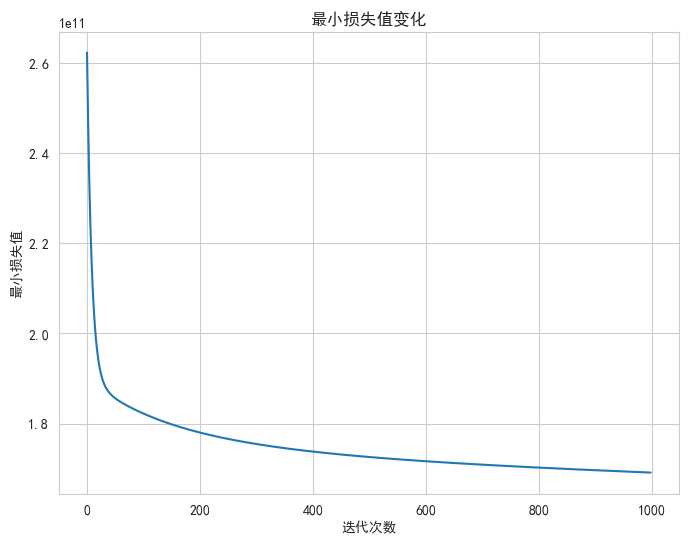

In [18]:
plt.figure(figsize=(8,6))
plt.plot(loss_his)
plt.xlabel('迭代次数')
plt.ylabel('最小损失值')
plt.title('最小损失值变化')
plt.show()

In [19]:
y_pred = predict(X_test, params)

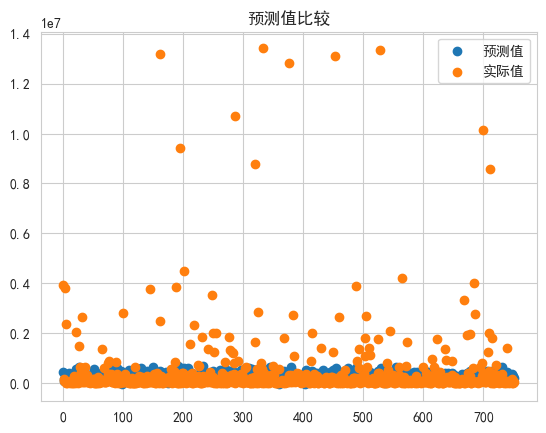

In [20]:
plt.figure()
plt.title('预测值比较')
plt.scatter(x = np.arange(len(y_pred)),y = y_pred,label = '预测值')
plt.scatter(x = np.arange(len(y_pred)),y = y_test,label = '实际值')
plt.legend()
plt.show()

[None]

Font 'default' does not have a glyph for '-' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '-' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '-' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '-' [U+2212], substituting with a dummy symbol.


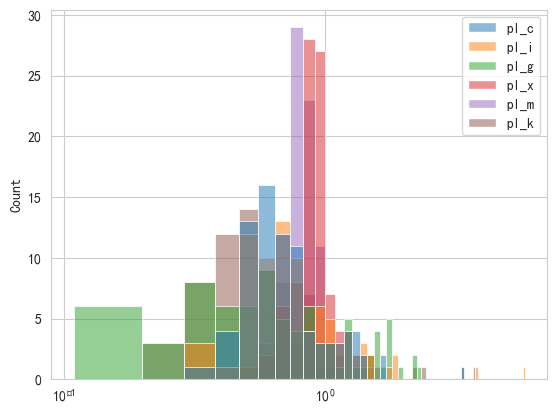

In [21]:
sns.histplot(X_train).set(xscale = 'log')


In [22]:
def r2_score(y_test, y_pred):
    y_avg = np.mean(y_test)
    ss_tot = np.sum((y_test - y_avg) ** 2)
    ss_res = np.sum((y_test - y_pred) ** 2)
    r2 = 1 - (ss_res / ss_tot)
    return r2

In [23]:
X_train


,pl_c,pl_i,pl_g,pl_x,pl_m,pl_k
787,0.816338,0.810104,1.314244,0.944392,0.772055,0.647712
512,0.544709,0.715860,0.663767,0.886189,0.837167,0.547066
556,0.667915,0.535828,0.856889,0.859254,0.747603,0.369056
516,0.700013,0.701687,0.558113,0.899660,0.736995,0.761191
487,0.757316,0.757851,1.490900,0.897967,0.770898,0.642033
...,...,...,...,...,...,...
568,0.642266,0.977884,0.559299,1.038710,0.976366,0.733681
49,1.341729,1.087647,1.899301,0.941202,0.879746,1.025814
498,0.553527,0.524413,0.625910,0.997681,0.650446,0.373318
746,0.661124,0.633336,0.119573,0.741246,0.753108,0.350326


In [24]:
r2_score(y_test,y_pred)

D:\software\anaconda3\lib\site-packages\numpy\core\fromnumeric.py:3438: FutureWarning: In a future version, DataFrame.mean(axis=None) will return a scalar mean over the entire DataFrame. To retain the old behavior, use 'frame.mean(axis=0)' or just 'frame.mean()'
  return mean(axis=axis, dtype=dtype, out=out, **kwargs)


rgdpe    0.009048
dtype: float64